In [24]:
import os
import shutil
import zipfile
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from google.colab import drive, files
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [25]:
# 1. MOUNT DRIVE & EXTRACT ZIP DATASET
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
ZIP_PATH_IN_DRIVE = "/content/drive/MyDrive/AssignmentData/bank-data.zip"
EXTRACT_DIR = "/content/bank_extracted"

if os.path.exists(ZIP_PATH_IN_DRIVE):
    print(f"Extracting {ZIP_PATH_IN_DRIVE}...")
    with zipfile.ZipFile(ZIP_PATH_IN_DRIVE, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)
    print("Extraction complete!")
else:
    raise FileNotFoundError(
        f"Could not find '{ZIP_PATH_IN_DRIVE}'. Check your folder/file name in Google Drive."
    )

Extracting /content/drive/MyDrive/AssignmentData/bank-data.zip...
Extraction complete!


In [27]:
# Removing hidden __MACOSX metadata folders and ._ hidden files
for root, dirs, files_list in os.walk(EXTRACT_DIR, topdown=False):
    if '__MACOSX' in root:
        shutil.rmtree(root, ignore_errors=True)
        continue
    for f in files_list:
        if f.startswith('._'):
            os.remove(os.path.join(root, f))

In [28]:
#locate the CSV file inside the extracted contents
csv_file_path = None
for root, dirs, files_list in os.walk(EXTRACT_DIR):
    for file in files_list:
        if file.endswith(".csv"):
            csv_file_path = os.path.join(root, file)
            break

if csv_file_path:
    print(f"Found CSV file at: {csv_file_path}")
    # Bank dataset usually uses ';' as delimiter
    df = pd.read_csv(csv_file_path, sep=";")
    print("Dataset loaded successfully! Shape:", df.shape)
else:
    raise FileNotFoundError("No CSV file found inside the extracted zip folder.")

Found CSV file at: /content/bank_extracted/bank-data/bank-full.csv
Dataset loaded successfully! Shape: (45211, 17)


In [29]:
# 2. PREPROCESSING & FEATURE ENGINEERING
df["y"] = df["y"].map({"yes": 1, "no": 0})

X = df.drop("y", axis=1)
y = df["y"]

X_encoded = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [30]:
# 3. TRAIN LOGISTIC REGRESSION MODEL
model = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)
model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)

In [31]:
# 4. EVALUATION METRICS
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print(f"\nAccuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["No Subscription", "Subscribed"]))


Accuracy Score: 84.60%
ROC-AUC Score: 0.9079

Classification Report:

                 precision    recall  f1-score   support

No Subscription       0.97      0.85      0.91      7985
     Subscribed       0.42      0.81      0.55      1058

       accuracy                           0.85      9043
      macro avg       0.70      0.83      0.73      9043
   weighted avg       0.91      0.85      0.87      9043



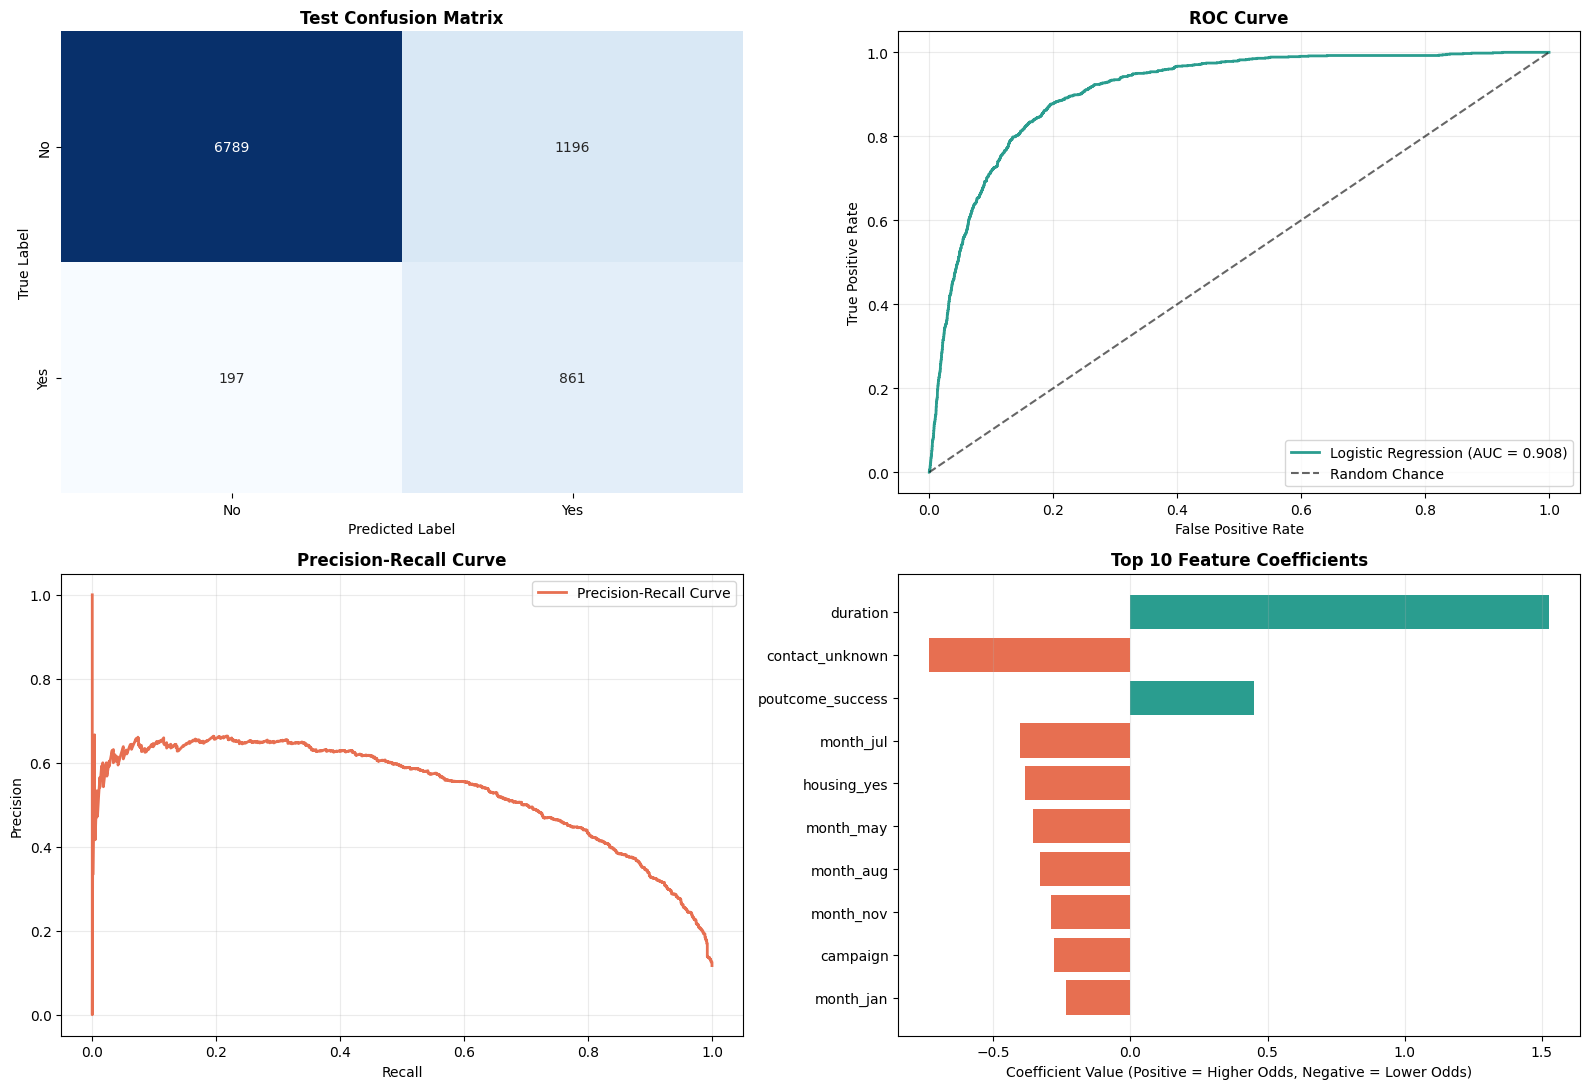


Total Misclassified Customers: 1393 / 9043

Top 10 Misclassified Customer Profiles (Sorted by Confidence):


,age,job,marital,education,balance,duration,Actual_Subscribed,Predicted_Subscribed,Prediction_Confidence
24095,30,admin.,married,secondary,1310,3284,0,1,1.000000
11386,45,technician,married,tertiary,3626,2485,0,1,0.999995
32986,30,blue-collar,single,secondary,103,2053,0,1,0.999977
42402,39,services,married,secondary,323,1804,0,1,0.999968
41893,60,management,married,secondary,0,1745,0,1,0.999968
12863,34,blue-collar,divorced,secondary,368,2201,0,1,0.999958
30344,60,unemployed,single,tertiary,361,1837,0,1,0.999952
3135,43,technician,single,secondary,28,2241,0,1,0.999862
31632,36,blue-collar,married,secondary,2454,1859,0,1,0.999851
37334,36,blue-collar,single,primary,1959,1966,0,1,0.999847


In [32]:
# 5.VISUALIZATION
from sklearn.metrics import precision_recall_curve
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    ax=axes[0, 0],
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"],
)
axes[0, 0].set_title("Test Confusion Matrix", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel("Predicted Label")
axes[0, 0].set_ylabel("True Label")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc_val = roc_auc_score(y_test, y_pred_proba)
axes[0, 1].plot(
    fpr,
    tpr,
    color="#2a9d8f",
    linewidth=2,
    label=f"Logistic Regression (AUC = {auc_val:.3f})",
)
axes[0, 1].plot([0, 1], [0, 1], "k--", alpha=0.6, label="Random Chance")
axes[0, 1].set_title("ROC Curve", fontsize=12, fontweight="bold")
axes[0, 1].set_xlabel("False Positive Rate")
axes[0, 1].set_ylabel("True Positive Rate")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.25)

# Precision-Recall Curve
precision, recall,_  = precision_recall_curve(y_test, y_pred_proba)
axes[1, 0].plot(
    recall,
    precision,
    color="#e76f51",
    linewidth=2,
    label="Precision-Recall Curve",
)
axes[1, 0].set_title("Precision-Recall Curve", fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel("Recall")
axes[1, 0].set_ylabel("Precision")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.25)

# Feature Importance
feature_names = X_encoded.columns
coefficients = model.coef_[0]
importance_df = pd.DataFrame({"Feature": feature_names, "Coefficient": coefficients})
importance_df["Abs_Coeff"] = importance_df["Coefficient"].abs()
top_10 = importance_df.sort_values(by="Abs_Coeff", ascending=False).head(10)

colors = ["#2a9d8f" if c > 0 else "#e76f51" for c in top_10["Coefficient"]]
axes[1, 1].barh(top_10["Feature"], top_10["Coefficient"], color=colors)
axes[1, 1].set_title("Top 10 Feature Coefficients", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("Coefficient Value (Positive = Higher Odds, Negative = Lower Odds)")
axes[1, 1].invert_yaxis()
axes[1, 1].grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.savefig("logistic_regression_performance.png", bbox_inches="tight")
plt.show()


# 6. MISCLASSIFICATION ANALYSIS

misclassified_mask = y_test.values != y_pred
misclassified_indices = np.where(misclassified_mask)[0]

print(f"\nTotal Misclassified Customers: {len(misclassified_indices)} / {len(y_test)}")

X_test_original = df.iloc[y_test.index].copy()
X_test_original["Actual_Subscribed"] = y_test.values
X_test_original["Predicted_Subscribed"] = y_pred
X_test_original["Prediction_Confidence"] = np.where(
    y_pred == 1, y_pred_proba, 1 - y_pred_proba
)

misclassified_df = X_test_original[misclassified_mask]

print("\nTop 10 Misclassified Customer Profiles (Sorted by Confidence):")
display_cols = [
    "age",
    "job",
    "marital",
    "education",
    "balance",
    "duration",
    "Actual_Subscribed",
    "Predicted_Subscribed",
    "Prediction_Confidence",
]
available_cols = [c for c in display_cols if c in misclassified_df.columns]

display(
    misclassified_df[available_cols]
    .sort_values(by="Prediction_Confidence", ascending=False)
    .head(10)
)